In [158]:
from pathlib import Path

import cv2
import numpy as np

from draftslice.core.io import load_image

files = sorted(Path("../data/images").glob("*.jpg")) +\
        sorted(Path("../data/drawing").glob("*.png"))
for i, file in enumerate(files):
    print(f"[{i}] - {file.stem}")

[0] - 1
[1] - 10
[2] - 11
[3] - 12
[4] - 13
[5] - 14
[6] - 15
[7] - 16
[8] - 17
[9] - 18
[10] - 19
[11] - 2
[12] - 20
[13] - 21
[14] - 3
[15] - 4
[16] - 5
[17] - 6
[18] - 7
[19] - 8
[20] - 9
[21] - АК-308.1-50 Вкладыш
[22] - АК-308.4-4 Муфта стержня
[23] - ИЖ-1614.1-4 Усилитель рычага
[24] - ИЖ-225.1-56 Кронштейн
[25] - РПЛ-20.01.036 Накладка
[26] - СОК-12.1-5 Вкладыш
[27] - СОК-5.1-10 Колодка прицельная
[28] - СОК-5.1-73 Колодка прицельная
[29] - СОК-АК.4-4 Муфта


In [159]:
IDX = 2
file = files[IDX]
file.stem

'11'

In [160]:
OCR_CACHE = Path('../data/output/ocr_cache/')
ocr_polys = np.load(OCR_CACHE / f"{file.stem.replace(' ', '_')}.npy")
len(ocr_polys)

15

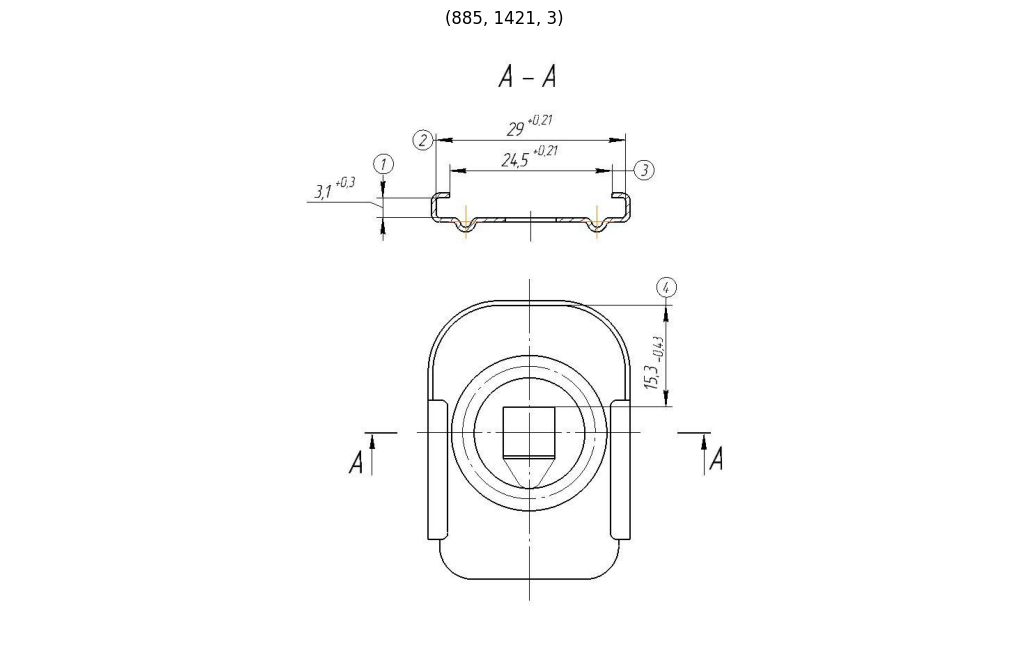

In [161]:
from matplotlib import pyplot as plt

img = load_image(str(file))
plt.figure(figsize=(16, 8))
plt.imshow(img)
plt.title(img.shape)
plt.axis("off")
plt.show()

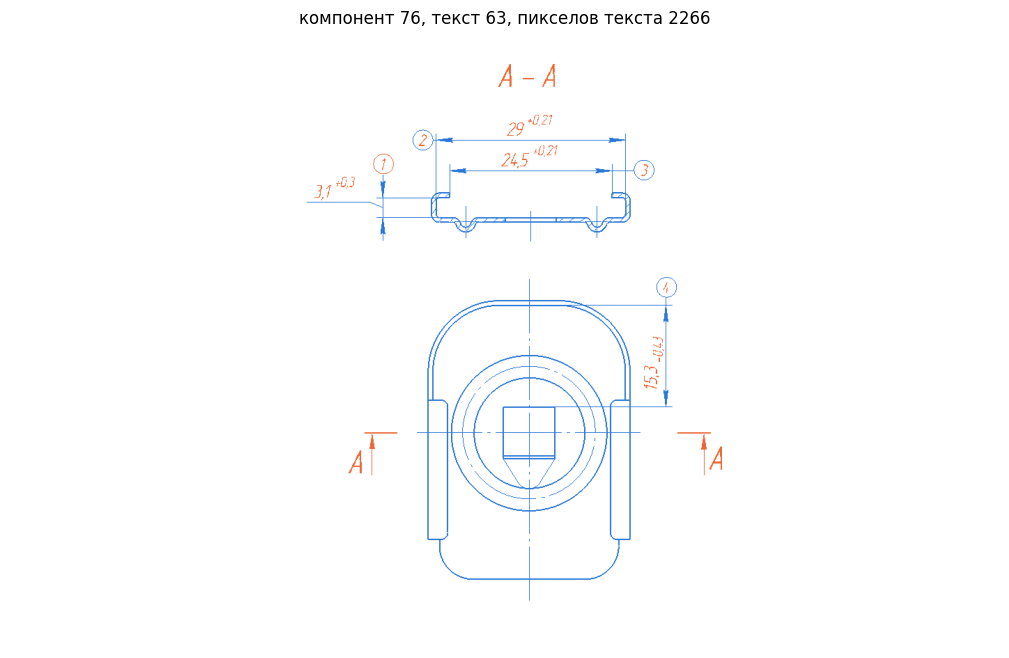

In [162]:
from draftslice.core.utils.image_utils import binarize_image, rgb_to_grayscale

gray = rgb_to_grayscale(img)
binary = binarize_image(gray) > 0

# tight - полигоны OCR как есть, wide - с полем в полвысоты строки (рамка вокруг надписи).
# Заливка по одному: fillPoly по набору заливает по чётности, перекрытие строк выпадает.
tight = np.zeros(binary.shape, np.uint8)
wide_boxes = []
for poly in ocr_polys:
    cv2.fillConvexPoly(tight, np.round(poly).astype(np.int32), 1)
    (cx, cy), (w, h), a = cv2.minAreaRect(poly)
    m = min(w, h) / 2
    wide_boxes.append(np.round(cv2.boxPoints(((cx, cy), (w + 2 * m, h + 2 * m), a))).astype(np.int32))

n_cc, labels, stats, _ = cv2.connectedComponentsWithStats(binary.astype(np.uint8), connectivity=8)
comp_area = stats[:, cv2.CC_STAT_AREA]
in_tight = np.bincount(labels[binary & (tight > 0)], minlength=n_cc)

# Рамка вокруг надписи - компонента целиком в поле ОДНОЙ надписи. Объединение полей соседних
# надписей накрывало выноску с кружком позиции (лист 10).
img_h, img_w = binary.shape
in_one_wide = np.zeros(n_cc, bool)
for box in wide_boxes:
    x0, y0 = np.maximum(box.min(0), 0)
    x1, y1 = np.minimum(box.max(0) + 1, (img_w, img_h))
    roi = np.zeros((y1 - y0, x1 - x0), np.uint8)
    cv2.fillConvexPoly(roi, box - (x0, y0), 1)
    sel = (roi > 0) & binary[y0:y1, x0:x1]
    in_one_wide |= np.bincount(labels[y0:y1, x0:x1][sel], minlength=n_cc) == comp_area

is_text = (2 * in_tight > comp_area) | in_one_wide
is_text[0] = False

text = is_text[labels]
ink = binary & ~text

canvas = np.full(img.shape, 255, np.uint8)
canvas[ink] = (42, 120, 214)    # краска - синим
canvas[text] = (235, 104, 52)   # снятый текст - оранжевым
plt.figure(figsize=(16, 8))
plt.imshow(canvas)
plt.title(f"компонент {n_cc - 1}, текст {is_text.sum()}, пикселов текста {text.sum()}")
plt.axis("off")
plt.show()


In [163]:
from skimage.morphology import skeletonize


def skeleton(ink, dist, tile=256):
    """Скелет Zhang-Suen по тайлам: тот же результат, что skeletonize(ink) 
    по всему листу, в 3-5 раз быстрее.

    Зачем тайлы. skeletonize за один проход снимает с краски один слой пикселов и повторяет проходы
    по всему листу, пока меняется хоть одна точка. Число проходов задаёт самая толстая клякса на листе,
    и каждый проход идёт по всему кадру, включая пустое поле. По тайлам пустые пропускаются сразу,
    а каждый тайл останавливается, как только в нём всё сошлось.

    Почему результат не меняется. Тайл скелетизируется с полем перекрытия m вокруг, в ответ идёт только
    его середина. Ложный край окна сдвигает решение соседей на 1 px за полупроход, проходов не больше
    max(dist), поэтому за поле m = 2 * max(dist) + 2 влияние края до середины не доходит.

    ink - маска краски, dist - расстояние до фона по ink (cv2.distanceTransform), tile - сторона тайла
    в px, на результат не влияет, только на скорость.
    """
    m = 2 * int(np.ceil(dist.max())) + 2
    h, w = ink.shape
    ii = cv2.integral(ink.astype(np.uint8))  # сумма краски в любом прямоугольнике за 4 обращения
    skel = np.zeros_like(ink)
    for y0 in range(0, h, tile):
        for x0 in range(0, w, tile):
            y1, x1 = min(y0 + tile, h), min(x0 + tile, w)
            if ii[y1, x1] - ii[y0, x1] - ii[y1, x0] + ii[y0, x0] == 0:  # пустой тайл
                continue
            a0, b0, a1, b1 = max(0, y0 - m), max(0, x0 - m), min(h, y1 + m), min(w, x1 + m)
            skel[y0:y1, x0:x1] = skeletonize(ink[a0:a1, b0:b1])[y0 - a0 : y1 - a0, x0 - b0 : x1 - b0]
    return skel


In [164]:
from skan import Skeleton, summarize

dist = cv2.distanceTransform(ink.astype(np.uint8), cv2.DIST_L2, cv2.DIST_MASK_PRECISE)
skel = skeleton(ink, dist)

graph = Skeleton(skel, source_image=dist)
branches = summarize(graph, separator="_")
branches


,skeleton_id,node_id_src,node_id_dst,branch_distance,branch_type,mean_pixel_value,stdev_pixel_value,image_coord_src_0,image_coord_src_1,image_coord_dst_0,image_coord_dst_1,coord_src_0,coord_src_1,coord_dst_0,coord_dst_1,euclidean_distance
0,0,24,85,9.000000,1,1.0,0.0,146,611,155,611,146,611,155,611,9.000000
1,0,25,342,9.000000,1,1.0,0.0,146,883,155,883,146,883,155,883,9.000000
2,0,50,99,4.828427,1,1.0,0.0,152,635,155,632,152,635,155,632,4.242641
3,0,51,330,3.828427,1,1.0,0.0,152,861,155,863,152,861,155,863,3.605551
4,0,81,81,95.497475,3,1.0,0.0,155,607,155,607,155,607,155,607,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307,12,7376,7406,3.000000,0,1.0,0.0,728,745,731,745,728,745,731,745,3.000000
308,1,7383,7417,8.000000,1,1.0,0.0,728,873,736,873,728,873,736,873,8.000000
309,1,7421,7669,46.000000,1,1.0,0.0,739,745,785,745,739,745,785,745,46.000000
310,1,7424,7669,156.597980,1,1.0,0.0,740,873,785,745,740,873,785,745,135.679770


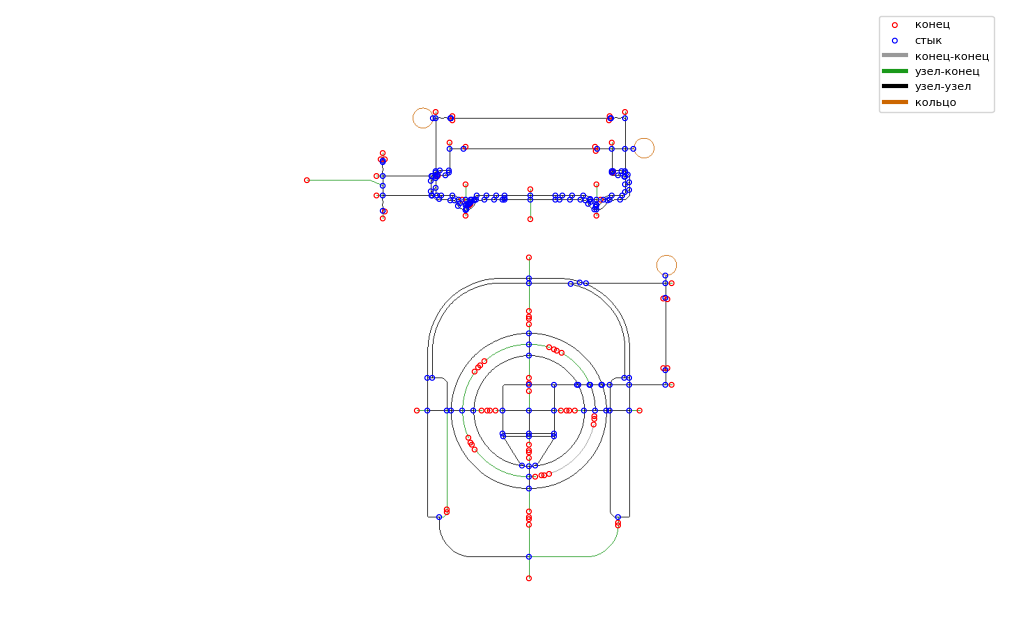

In [165]:
# Номер ветки в каждой точке скелета (0 - не скелет). Точка узла общая у нескольких веток - в ней одна из них.
branch_lbl = graph.path_label_image()
# Ветки - цветом по branch_type, узлы - кружками: красный - конец линии, синий - стык.
TYPE_COLOR = {0: (0.6, 0.6, 0.6), 1: (0.1, 0.6, 0.1), 2: (0.0, 0.0, 0.0), 3: (0.8, 0.4, 0.0)}
TYPE_NAME = {0: "конец-конец", 1: "узел-конец", 2: "узел-узел", 3: "кольцо"}

# Цвет ветки по её номеру: branch_lbl хранит номер + 1, 0 - фон (белый).
palette = np.ones((graph.n_paths + 1, 3))
palette[1:] = np.array([TYPE_COLOR[t] for t in branches.branch_type])
k = max(1, skel.shape[1] // 1500)  # утолщение только для обзора большого листа
view = cv2.dilate(branch_lbl.astype(np.float32), np.ones((k, k), np.uint8)).astype(np.int32)

# Узлы - концы веток; тип по степени точки: 1 - конец линии, >= 3 - стык.
node_ids = np.unique(branches[["node_id_src", "node_id_dst"]].to_numpy())
ny, nx = graph.coordinates[node_ids].T
deg = graph.degrees[node_ids]

plt.figure(figsize=(16, 8))
plt.imshow(palette[view])
plt.scatter(nx[deg == 1], ny[deg == 1], s=12, facecolors="none", edgecolors="red", linewidths=0.8, label="конец")
plt.scatter(nx[deg >= 3], ny[deg >= 3], s=12, facecolors="none", edgecolors="blue", linewidths=0.8, label="стык")
for t, c in TYPE_COLOR.items():
    plt.plot([], [], color=c, lw=3, label=TYPE_NAME[t])
plt.legend(loc="upper right", fontsize=8)
plt.axis("off")
plt.show()


In [166]:
import pandas as pd


def tangents(pts, k=3):
    """Единичное направление (dy, dx) линии в каждой её точке: хорда от точки на k шагов назад
    к точке на k шагов вперёд (у концов окно обрезается). Хорда в 6 px - ошибка направления ~10°.
    pts - точки линии по порядку, (n, 2)."""
    i = np.arange(len(pts))
    d = (pts[np.minimum(i + k, len(pts) - 1)] - pts[np.maximum(i - k, 0)]).astype(np.float32)
    norm = np.hypot(d[:, 0], d[:, 1])
    return d / np.maximum(norm, 1e-9)[:, None]  # у линии из 1 точки - (0, 0)

def sections(pts, tang, ink_f, dist, step=0.5):
    """Толщина линии в каждой её точке - сечение по нормали к скелету, px.

    От точки скелета идём по нормали в обе стороны с шагом step и суммируем краску, взятую
    билинейно (дробно на краю пиксела), пока не выйдем в фон: это длина сечения в краске.
    У линии в 1 px ~1 под любым углом (у 2*dist-1 диагонали 1 и 3 px одинаковы - 1.83).
    Сечение не длиннее max(dist) линии + 1 px в каждую сторону: дальше - уже чужая линия стыка.
    У точки без направления - NaN.

    pts - точки линии по порядку (n, 2), tang - направления в них, ink_f - краска float32 (0/1).
    """
    r = int(np.ceil(dist[pts[:, 0], pts[:, 1]].max())) + 1
    s = np.arange(1, int(r / step) + 1, dtype=np.float32) * step
    nrm = np.stack([tang[:, 1], -tang[:, 0]], 1).astype(np.float32)  # нормаль (dy, dx)
    tot = ink_f[pts[:, 0], pts[:, 1]] * step  # центр сечения
    for sign in (1, -1):
        q = (pts[:, None, :] + sign * s[None, :, None] * nrm[:, None, :]).astype(np.float32)  # (n, len(s), 2)
        v = cv2.remap(ink_f, q[..., 1], q[..., 0], cv2.INTER_LINEAR, borderValue=0)
        tot = tot + (v * np.cumprod(v > 0, axis=1)).sum(1) * step  # только до первого фона
    tot[np.abs(nrm).sum(1) == 0] = np.nan
    return tot

def end_dir(pts, dist, at_start, w=6):
    """Направление конца линии в узел (dy, dx) и его погрешность, градусы.

    Возле стыка скелет изогнут: он идёт по пятну стыка, а не по линии. Пятно - круг радиуса dist
    в точке узла, поэтому хорда начинается в dist шагах от узла и идёт на w шагов вглубь линии
    (w = 6 ~ 1 / tg 10°). Линия короче - хорда по всей длине. Погрешность: концы хорды квантованы
    на ±0.5 px, atan(1 / длина хорды) - у 6 px ~10°, у 3 px ~18°.
    pts - точки линии по порядку, at_start - конец в начале pts (узел src) или в конце (dst).
    """
    p = pts if at_start else pts[::-1]  # p[0] - точка узла
    near = min(int(np.ceil(dist[p[0, 0], p[0, 1]])), len(p) - 1)
    far = min(near + w, len(p) - 1)
    if far - near < w:  # на хорду за пятном не хватает длины - берём всю линию
        near, far = 0, len(p) - 1
    d = (p[near] - p[far]).astype(np.float32)  # от глубины линии к узлу
    chord = np.hypot(d[0], d[1])
    if chord == 0:  # линия из одной точки - направления нет
        return np.zeros(2, np.float32), 180.0
    return d / chord, float(np.degrees(np.arctan(1 / chord)))

ink_f = ink.astype(np.float32)
# Степень точки скелета по картинке: у конца линии проверяем, стык ли там.
deg_img = np.zeros(skel.shape, np.int8)
deg_img[graph.coordinates[:, 0], graph.coordinates[:, 1]] = np.minimum(graph.degrees, 127)
MIN_SECT = 3  # меньше чистых сечений - берём все: короткий кусок контура между штрихами


def junction_mask(pts):
    """Точки линии вне пятен стыков на её концах: в пятне (ближе dist узла) сечение меряет чужую линию."""
    keep = np.ones(len(pts), bool)
    for p0, order in ((pts[0], slice(None)), (pts[-1], slice(None, None, -1))):
        if deg_img[p0[0], p0[1]] >= 3:
            r = int(np.ceil(dist[p0[0], p0[1]]))
            keep[np.arange(len(pts))[order][:r]] = False
    return keep

def line_features(pts):
    """Признаки одной линии - строка датафрейма."""
    t = tangents(pts)
    sect = sections(pts, t, ink_f, dist)
    ok = np.isfinite(sect)
    clean = ok & junction_mask(pts)
    sect = sect[clean] if clean.sum() >= MIN_SECT else sect[ok]

    if not len(sect):
        return {"n_pts": len(pts), "n_sect": 0, "thickness": np.nan, "thickness_std": np.nan}
    med = np.median(sect)

    d_src, err_src = end_dir(pts, dist, at_start=True)
    d_dst, err_dst = end_dir(pts, dist, at_start=False)

    return {
        "n_pts": len(pts),
        "n_sect": len(sect),
        "thickness": med,
        # 1.4826 * MAD - то же, что std при обычном шуме, но сечения стыков его не раздувают
        "thickness_std": 1.4826 * np.median(np.abs(sect - med)),
        "dir_src_y": d_src[0], "dir_src_x": d_src[1], "dir_src_err": err_src,
        "dir_dst_y": d_dst[0], "dir_dst_x": d_dst[1], "dir_dst_err": err_dst,
    }


ink_f = ink.astype(np.float32)

rows = [line_features(graph.path_coordinates(i).astype(int)) for i in range(graph.n_paths)]
features = pd.DataFrame(rows)
branches = pd.concat([branches, features], axis=1)
branches.head()


,skeleton_id,node_id_src,node_id_dst,branch_distance,branch_type,mean_pixel_value,stdev_pixel_value,image_coord_src_0,image_coord_src_1,image_coord_dst_0,...,n_pts,n_sect,thickness,thickness_std,dir_src_y,dir_src_x,dir_src_err,dir_dst_y,dir_dst_x,dir_dst_err
0,0,24,85,9.000000,1,1.0,0.0,146,611,155,...,10,8,1.000000,0.000000,-1.000000,0.000000,9.462322,1.000000,0.000000,9.462322
1,0,25,342,9.000000,1,1.0,0.0,146,883,155,...,10,9,1.000000,0.000000,-1.000000,0.000000,9.462322,1.000000,0.000000,9.462322
2,0,50,99,4.828427,1,1.0,0.0,152,635,155,...,5,5,4.463867,4.169812,-0.707107,0.707107,13.262676,0.707107,-0.707107,13.262676
3,0,51,330,3.828427,1,1.0,0.0,152,861,155,...,4,4,6.147217,1.613993,-0.832050,-0.554700,15.501358,0.832050,0.554700,15.501358
4,0,81,81,95.497475,3,1.0,0.0,155,607,155,...,82,80,1.042480,0.062982,0.948683,0.316228,8.984877,-0.948683,0.316228,8.984877


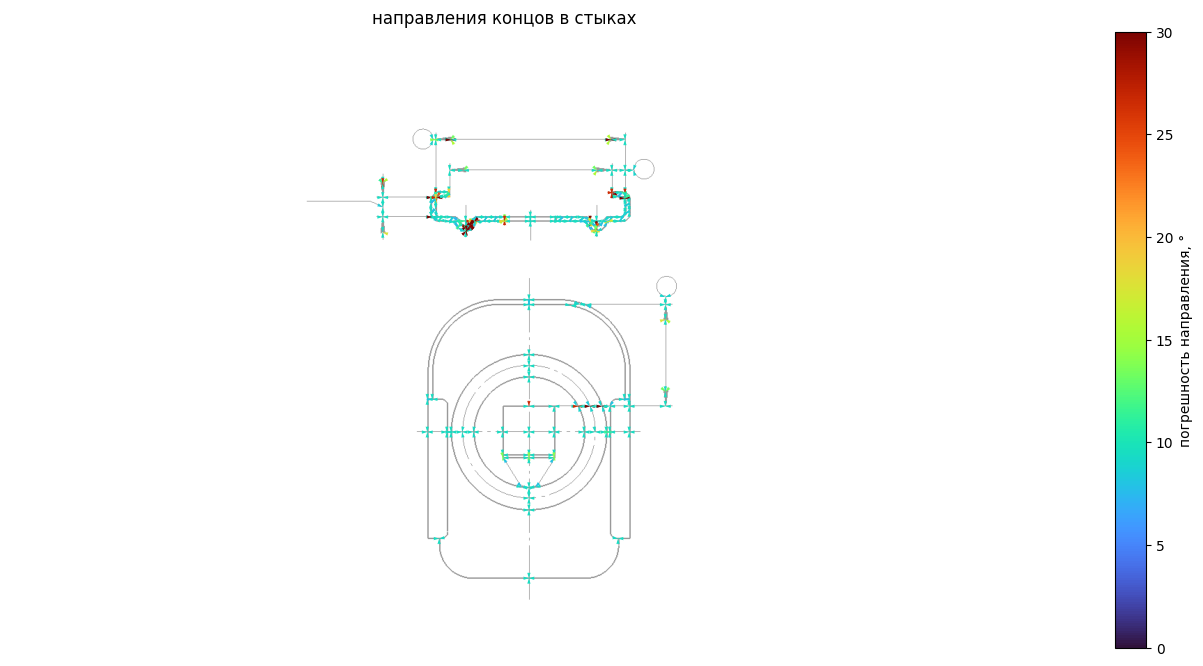

In [167]:
jn = graph.degrees >= 3  # стык
fig, ax = plt.subplots(figsize=(30, 8))
ax.imshow(~ink, cmap="gray", alpha=0.4)
for end in ("src", "dst"):
    node = branches[f"node_id_{end}"].to_numpy()
    m = jn[node]
    y, x = graph.coordinates[node[m]].T
    dy, dx = branches[f"dir_{end}_y"].to_numpy()[m], branches[f"dir_{end}_x"].to_numpy()[m]
    # стрелка смотрит из линии в узел; цвет - погрешность направления
    q = ax.quiver(x - 8 * dx, y - 8 * dy, dx, dy, branches[f"dir_{end}_err"].to_numpy()[m],
                  angles="xy", scale_units="xy", scale=1 / 8, width=0.0015, cmap="turbo", clim=(0, 30))
fig.colorbar(q, ax=ax, label="погрешность направления, °")
ax.set_title("направления концов в стыках")
ax.axis("off")
plt.show()


In [168]:
from scipy.sparse import coo_matrix
from scipy.sparse.csgraph import connected_components


def node_radius(node):
    """Радиус пятна в точке узла - dist, px."""
    y, x = graph.coordinates[node].T
    return dist[y, x]


src, dst = branches.node_id_src.to_numpy(), branches.node_id_dst.to_numpy()
# Перемычка: ветка между двумя стыками короче суммы их радиусов - пятна перекрываются, это один
# стык (крест X, распавшийся у Zhang-Suen на два Y).
bridge = ((branches.branch_type == 2) & (branches.branch_distance <= node_radius(src) + node_radius(dst))).to_numpy()
n = len(graph.coordinates)
adj = coo_matrix((np.ones(bridge.sum()), (src[bridge], dst[bridge])), shape=(n, n))
_, junc = connected_components(adj, directed=False)  # номер стыка для каждой точки скелета

deg = graph.degrees
# Отросток: ветка стык-конец не длиннее радиуса пятна стыка - волосок скелета внутри пятна.
spur = ((branches.branch_type == 1).to_numpy()
        & (branches.branch_distance.to_numpy()
           <= np.maximum(np.where(deg[src] >= 3, node_radius(src), 0),
                         np.where(deg[dst] >= 3, node_radius(dst), 0))))
branches["bridge"] = bridge | spur  # и перемычки, и отростки - часть стыка, а не линии

branches["junc_src"], branches["junc_dst"] = junc[src], junc[dst]
print(f"перемычек {bridge.sum()} - столько пар узлов слилось в один стык")


перемычек 30 - столько пар узлов слилось в один стык


In [169]:
def junction_ends(branches):
    """Концы веток в стыках - строка на конец: стык, ветка, направление в стык, погрешность, толщина.
    Перемычки не входят: они внутри стыка, а не линии, выходящие из него."""
    deg = graph.degrees
    parts = []
    for end in ("src", "dst"):
        e = branches[(deg[branches[f"node_id_{end}"]] >= 3) & ~branches.bridge]
        parts.append(pd.DataFrame({
            "junc": e[f"junc_{end}"], "branch": e.index, "end": end,
            "dy": e[f"dir_{end}_y"], "dx": e[f"dir_{end}_x"], "err": e[f"dir_{end}_err"],
            "thickness": e.thickness, "thickness_std": e.thickness_std, "n_sect": e.n_sect,
        }))
    return pd.concat(parts, ignore_index=True)


ends = junction_ends(branches)
print(f"концов в стыках {len(ends)}, стыков {ends.junc.nunique()}")
print("концов на стык:", ends.groupby("junc").size().value_counts().sort_index().to_dict())


концов в стыках 472, стыков 135
концов на стык: {3: 77, 4: 53, 5: 4, 9: 1}


In [170]:
b = branches[~branches.bridge]
long_b = b[b.branch_distance > 4 * np.nanmedian(b.thickness)]
sheet_std = float(np.median(long_b.thickness_std))  # разброс толщины вдоль линии на этом листе
print(f"разброс толщины на листе {sheet_std:.2f} px")


разброс толщины на листе 0.00 px


In [171]:
MAX_TURN = 10  # поворот сквозь стык, градусы: больше - это уже примкнувшая линия, а не продолжение


def turn_angle(a, b):
    """Поворот при переходе из конца a в конец b через стык, градусы; 0 - прямое продолжение.
    Оба направления смотрят в стык, поэтому у продолжения они противоположны."""
    cos = -(a.dy * b.dy + a.dx * b.dx)
    return float(np.degrees(np.arccos(np.clip(cos, -1, 1))))


QUANT = 1.0  # толщина куска квантована до 1 px (у линии вдоль сетки сечения целые): 3 и 4 px - одна линия


def same_thickness(a, b):
    if np.isnan(a.thickness) or np.isnan(b.thickness):
        return True
    return abs(a.thickness - b.thickness) <= QUANT + np.hypot(max(a.thickness_std, sheet_std),
                                                              max(b.thickness_std, sheet_std))



def match_junction(e):
    """Пары концов в одном стыке: жадно от самой соосной, каждый конец - не больше чем в одной паре.

    Допуск поворота - MAX_TURN плюс погрешность направлений обоих концов: короткий кусок меряется
    грубее, и без поправки его настоящее продолжение отбрасывалось бы. Ветка сама с собой (кольцо
    обоими концами в одном стыке) не пара."""
    cand = []
    rows = list(e.itertuples())
    for i in range(len(rows)):
        for j in range(i + 1, len(rows)):
            a, b = rows[i], rows[j]
            if a.branch == b.branch:
                continue
            ang = turn_angle(a, b)
            if ang <= MAX_TURN + np.hypot(a.err, b.err) and same_thickness(a, b):
                cand.append((ang + np.hypot(a.err, b.err), a.Index, b.Index, a.branch, b.branch))

    used, pairs = set(), []
    for ang, ia, ib, ba, bb in sorted(cand):
        if ia not in used and ib not in used:
            used |= {ia, ib}
            pairs.append((ba, bb))
    return pairs


pairs = [p for _, e in ends.groupby("junc") if len(e) > 1 for p in match_junction(e)]
pairs = np.array(pairs, dtype=np.int64).reshape(-1, 2)

# Линия - компонента связности веток по парам: одна линия может проходить через много стыков.
adj = coo_matrix((np.ones(len(pairs)), (pairs[:, 0], pairs[:, 1])), shape=(graph.n_paths, graph.n_paths))
_, line = connected_components(adj, directed=False)
branches["line"] = line
print(f"пар {len(pairs)}, веток {graph.n_paths} -> линий {len(np.unique(line))}")


пар 154, веток 312 -> линий 160


In [176]:
pair_set = {tuple(sorted(p)) for p in pairs.tolist()}


def junction_line(e):
    """Линия, которой принадлежит пятно стыка: самая толстая из проходящих сквозь него (пара в этом
    стыке); сквозных нет (угол контура, конец) - самая толстая из примыкающих. -1 - не нашлось."""
    br = e.branch.to_numpy()
    through = [b for i, b in enumerate(br) for c in br[i + 1:] if tuple(sorted((b, c))) in pair_set]
    ln = branches.line.to_numpy()[through if through else br]
    t = lines.thickness.reindex(ln).to_numpy()
    return int(ln[np.nanargmax(t)]) if np.isfinite(t).any() else -1


jline = {j: junction_line(e) for j, e in ends.groupby("junc")}

# Перемычки и отростки получают класс и толщину линии своего стыка.
part = np.flatnonzero(branches.bridge.to_numpy())
jj = np.where(graph.degrees[src[part]] >= 3, branches.junc_src.to_numpy()[part], branches.junc_dst.to_numpy()[part])
own = np.array([jline.get(j, -1) for j in jj])
part, own = part[own >= 0], own[own >= 0]
branches.loc[part, "group"] = lines.group.reindex(own).to_numpy()
branches.loc[part, "thickness"] = lines.thickness.reindex(own).to_numpy()
print(f"кусков стыков {len(jj)}, получили класс линии {len(part)}, остались серыми {len(jj) - len(part)}")


кусков стыков 33, получили класс линии 33, остались серыми 0


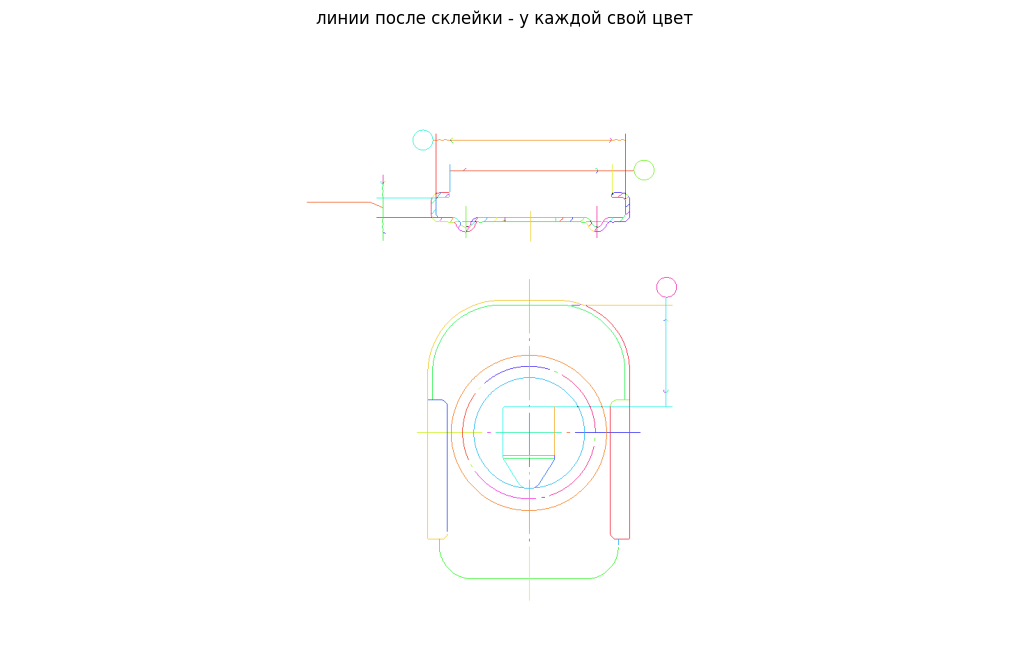

In [177]:
from draw import colorize

# Цвет по номеру линии; перемычки - чёрные (часть стыка, а не линия).
lbl = np.zeros(graph.n_paths + 1, np.int64)
lbl[1:] = branches.line.to_numpy() + 1
canvas = colorize(lbl[view])
canvas[view == 0] = 1.0
canvas[np.isin(view, np.flatnonzero(bridge) + 1)] = 0.0

plt.figure(figsize=(16, 8))
plt.imshow(canvas)
plt.title("линии после склейки - у каждой свой цвет")
plt.axis("off")
plt.show()


In [178]:
def wmedian(x, w):
    """Взвешенная медиана."""
    o = np.argsort(x)
    c = np.cumsum(w[o])
    return x[o][np.searchsorted(c, c[-1] / 2)]


def otsu_weighted(x, w):
    """Порог Otsu по x с весами w: разрез с наибольшей межклассовой дисперсией, только между разными значениями."""
    o = np.argsort(x)
    x, w = x[o], w[o]
    cw, cwx = np.cumsum(w), np.cumsum(w * x)
    w0, w1 = cw[:-1], cw[-1] - cw[:-1]
    between = w0 * w1 * (cwx[:-1] / w0 - (cwx[-1] - cwx[:-1]) / w1) ** 2
    between[x[1:] == x[:-1]] = -1
    i = int(np.argmax(between))
    return (x[i] + x[i + 1]) / 2


def split2(x, w):
    """Порог и медианы двух групп: Otsu как начало, затем порог посередине между взвешенными медианами
    групп, до сходимости. Otsu при неравных группах сдвигает разрез к меньшей, а среднее толстых
    раздувают наконечники стрелок; медиана к таким хвостам нечувствительна.
    Меньше двух разных значений - (NaN, NaN, NaN): делить нечего."""
    if np.unique(x).size < 2:
        return np.nan, np.nan, np.nan
    b = otsu_weighted(x, w)  # разрез между разными значениями - обе группы не пустые
    for _ in range(100):
        lo, hi = x <= b, x > b
        nb = (wmedian(x[lo], w[lo]) + wmedian(x[hi], w[hi])) / 2
        if nb == b or not ((x <= nb).any() and (x > nb).any()):
            break
        b = nb
    lo, hi = x <= b, x > b
    return b, wmedian(x[lo], w[lo]), wmedian(x[hi], w[hi])

def line_thickness(b):
    """Толщина линии - взвешенная медиана толщин её веток, вес - число сечений ветки.
    NaN, если ни одна ветка линии не измерена."""
    b = b[b.thickness.notna() & (b.n_sect > 0)]
    return wmedian(b.thickness.to_numpy(), b.n_sect.to_numpy()) if len(b) else np.nan


# Перемычки - часть стыка, а не линии: в линии не входят и остаются серыми.
lines = (branches[~branches.bridge].groupby("line")
         .apply(lambda b: pd.Series({"thickness": line_thickness(b), "length": b.branch_distance.sum()})))

measured = lines.thickness.notna() & (lines.length > 0)
x = lines.thickness[measured].to_numpy()
w = lines.length[measured].to_numpy()  # вес линии - её полная длина
bound, thin_med, thick_med = split2(x, w)

lines["group"] = np.where(measured, (lines.thickness > bound).astype(int), -1)
branches["group"] = branches.line.map(lines.group).fillna(-1).astype(int)  # класс линии - всем её веткам
print(f"порог {bound:.2f} px, медиана тонких {thin_med:.2f}, толстых {thick_med:.2f}")
print(f"линий: тонких {(lines.group == 0).sum()}, толстых {(lines.group == 1).sum()}, "
      f"не измерено {(lines.group == -1).sum()}")


порог 1.50 px, медиана тонких 1.00, толстых 2.00
линий: тонких 52, толстых 75, не измерено 0


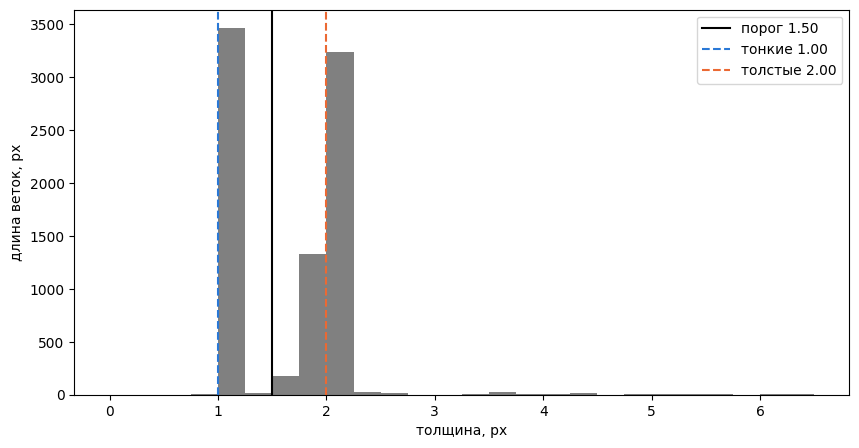

In [179]:
GROUP_COLOR = {-1: (0.75, 0.75, 0.75), 0: (0.16, 0.47, 0.84), 1: (0.92, 0.41, 0.2)}

# Гистограмма толщин с весом по длине: видно, есть ли два пика и где прошёл разрез.
plt.figure(figsize=(10, 5))
plt.hist(x, bins=np.arange(0, x.max() + 0.25, 0.25), weights=w, color="0.5")
plt.axvline(bound, color="k", label=f"порог {bound:.2f}")
plt.axvline(thin_med, color=GROUP_COLOR[0], ls="--", label=f"тонкие {thin_med:.2f}")
plt.axvline(thick_med, color=GROUP_COLOR[1], ls="--", label=f"толстые {thick_med:.2f}")
plt.xlabel("толщина, px")
plt.ylabel("длина веток, px")
plt.legend()
plt.show()


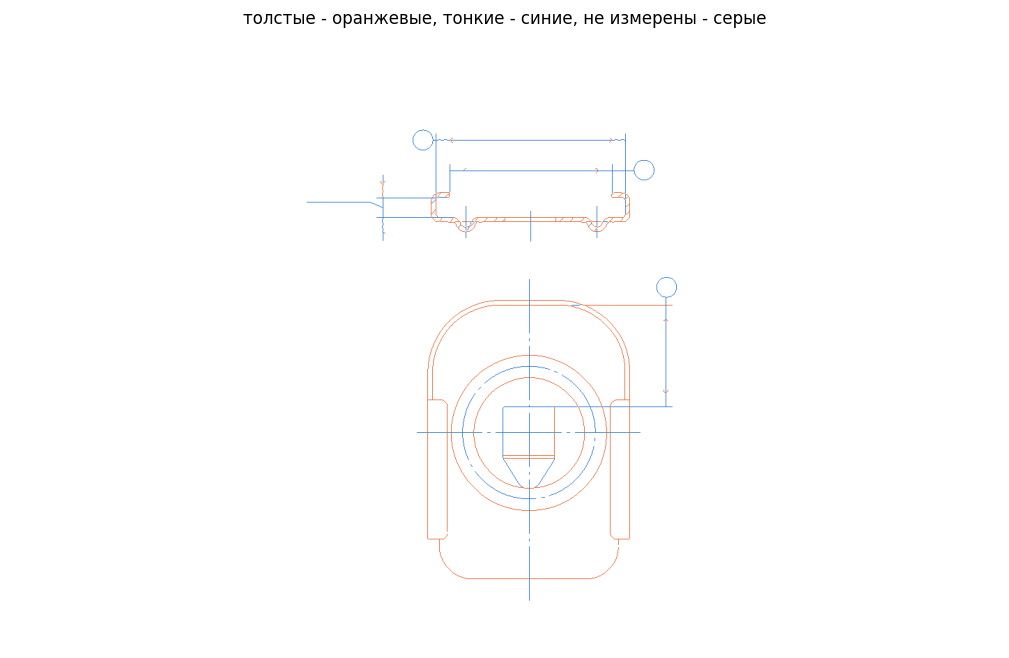

In [180]:
# Лист: ветка - цветом своей группы (branch_lbl хранит номер ветки + 1, 0 - фон).
palette = np.ones((graph.n_paths + 1, 3))
palette[1:] = np.array([GROUP_COLOR[g] for g in branches.group])
k = max(1, skel.shape[1] // 1500)
view = cv2.dilate(branch_lbl.astype(np.float32), np.ones((k, k), np.uint8)).astype(np.int32)

plt.figure(figsize=(16, 8))
plt.imshow(palette[view])
plt.title("толстые - оранжевые, тонкие - синие, не измерены - серые")
plt.axis("off")
plt.show()
